In [1]:
import pandas as pd 
import seaborn as sns 
import plotly.express as px
import matplotlib.pyplot as plt

ri = pd.read_csv("Rental_income_citywide.csv")
ri

/tmp/ipykernel_2041/2870111445.py:6: DtypeWarning: Columns (0: Total Units 1, 1: Total Units 2, 2: Total Units 3, 3: Expense per SqFt 3) have mixed types. Specify dtype option on import or set low_memory=False.
  ri = pd.read_csv("Rental_income_citywide.csv")


,Boro-Block-Lot,Address,Neighborhood,Building Classification,Total Units,Year Built,Gross SqFt,Estimated Gross Income,Gross Income per SqFt,Estimated Expense,...,Gross SqFt 3,Estimated Gross Income 3,Gross Income per SqFt 3,Estimated Expense 3,Expense per SqFt 3,Net Operating Income 3,Full Market Value 3,Market Value per SqFt 3,Distance from Co-op in miles 2,Report Year
0,1-00011-0014,26 BEAVER STREET,FINANCIAL,D4 -ELEVATOR,21,1909,"51,387","2,399,773",46.70,"940,382",...,"335,746","15,679,338",46.70,"6,144,152",18.3,"9,535,186","71,229,000",212.15,0.21,2019
1,1-00028-0001,3 HANOVER SQUARE,FINANCIAL,D0 -ELEVATOR,211,1926,"239,121","9,462,018",39.57,"2,907,711",...,"473,460","18,706,405",39.51,"6,538,483",13.81,"12,167,922","145,268,000",306.82,0.10,2019
2,1-00094-0001,80 GOLD STREET,SOUTHBRIDGE,D4 -ELEVATOR,"1,652",1971,"2,155,492","68,113,547",31.60,"27,676,517",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019
3,1-00100-0026,138 NASSAU STREET,SOUTHBRIDGE,D4 -ELEVATOR,43,1901,"79,422","3,130,815",39.42,"882,378",...,"31,715","1,205,170",38.00,"319,370",10.07,"885,800","10,485,000",330.60,0.27,2019
4,1-00117-0001,185 PARK ROW,CIVIC CENTER,D4 -ELEVATOR,465,1960,"515,425","25,889,798",50.23,"10,354,888",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49255,5-02925-0432,361 SKYLINE DRIVE,CONCORD-FOX HILLS,C6 -WALK-UP,11,1999,"21,780","504,425",23.16,"207,346",...,"9,750","225,810",23.16,"92,820",9.52,"132,990","994,000",101.95,1.00,2022
49256,5-02925-0450,295 SKYLINE DRIVE,CONCORD-FOX HILLS,C6 -WALK-UP,11,2000,"21,865","506,393",23.16,"208,155",...,"9,750","225,810",23.16,"92,820",9.52,"132,990","994,000",101.95,1.00,2022
49257,5-02925-0479,46 CIRCLE LOOP,CONCORD-FOX HILLS,C6 -WALK-UP,19,2000,"37,220","777,898",20.90,"386,344",...,"19,386","405,167",20.90,"201,227",10.38,"203,941","1,879,000",96.93,0.50,2022
49258,5-04640-0022,3745 AMBOY ROAD,GREAT KILLS,C6 -WALK-UP,36,1974,"26,490","508,343",19.19,"228,079",...,"10,200","199,002",19.51,"88,536",8.68,"110,466","844,000",82.75,2.51,2022


In [2]:
ri.info()

<class 'pandas.DataFrame'>
RangeIndex: 49260 entries, 0 to 49259
Data columns (total 60 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Boro-Block-Lot                  49260 non-null  str    
 1   Address                         49260 non-null  str    
 2   Neighborhood                    49260 non-null  str    
 3   Building Classification         49260 non-null  str    
 4   Total Units                     49260 non-null  str    
 5   Year Built                      49260 non-null  int64  
 6   Gross SqFt                      49260 non-null  str    
 7   Estimated Gross Income          49260 non-null  str    
 8   Gross Income per SqFt           49260 non-null  float64
 9   Estimated Expense               49260 non-null  str    
 10  Expense per SqFt                49260 non-null  float64
 11  Net Operating Income            49260 non-null  str    
 12  Full Market Value               49260 non-n

In [3]:

print(ri['Neighborhood'].unique())

<StringArray>
[              'FINANCIAL',             'SOUTHBRIDGE',
            'CIVIC CENTER',                 'TRIBECA',
               'CHINATOWN',                    'SOHO',
         'LOWER EAST SIDE',           'ALPHABET CITY',
            'EAST VILLAGE',               'BAY RIDGE',
 ...
            'DONGAN HILLS',              'GRANT CITY',
             'GREAT KILLS', 'GREAT KILLS-BAY TERRACE',
             'CITY ISLAND',         'CARROLL GARDENS',
                'RED HOOK',        'ROOSEVELT ISLAND',
            'NEW BRIGHTON',       'WEST NEW BRIGHTON']
Length: 297, dtype: str


In [4]:
ri['Neighborhood'].value_counts()

Neighborhood
UPPER EAST SIDE (79-96)     3181
UPPER EAST SIDE (59-79)     2355
UPPER WEST SIDE (79-96)     1679
CHELSEA                     1245
JACKSON HEIGHTS             1218
                            ... 
SO. JAMAICA-BAISLEY PARK       1
ARROCHAR-SHORE ACRES           1
DONGAN HILLS                   1
GREAT KILLS-BAY TERRACE        1
NEW BRIGHTON                   1
Name: count, Length: 297, dtype: int64

In [5]:
import pandas as pd

# Set 0: Base columns without numbers
set0 = ri[
    [
        "Neighborhood",
        "Building Classification",
        "Total Units",
        "Year Built",
        "Estimated Gross Income",
        "Estimated Expense",
        "Net Operating Income",
    ]
]

# Set 1: Columns ending in 1
set1 = ri[
    [
        "Neighborhood 1",
        "Building Classification 1",
        "Total Units 1",
        "Year Built 1",
        "Estimated Gross Income 1",
        "Estimated Expense 1",
         "Net Operating Income 1"
    ]
].rename(columns=lambda x: x.rstrip(" 1"))

# Set 2: Columns ending in 2
set2 = ri[
    [
        "Neighborhood 2",
        "Building Classification 2",
        "Total Units 2",
        "Year Built 2",
        "Estimated Gross Income 2",
        "Estimated Expense 2",
         "Net Operating Income 2"
    ]
].rename(columns=lambda x: x.rstrip(" 2"))

# Set 3: Columns ending in 3
set3 = ri[
    [
        "Neighborhood 3",
        "Building Classification 3",
        "Total Units 3",
        "Year Built 3",
        "Estimated Gross Income 3",
        "Estimated Expense 3",
         "Net Operating Income 3"
    ]
].rename(columns=lambda x: x.rstrip(" 3"))

# Stack all four horizontal sets into one single vertical table
stacked_ri = pd.concat([set0, set1, set2, set3], axis=0, ignore_index=True)

# Drop rows where the Neighborhood is blank (cleans up any empty column blocks)
stacked_ri = stacked_ri.dropna(subset=["Neighborhood"])

# View your final stacked dataset
stacked_ri

# AI Disclosure: Used Gemini AI to help me generate the code to create this table from having 60 columns to only 6

,Neighborhood,Building Classification,Total Units,Year Built,Estimated Gross Income,Estimated Expense,Net Operating Income
0,FINANCIAL,D4 -ELEVATOR,21,1909.0,"2,399,773","940,382","1,459,391"
1,FINANCIAL,D0 -ELEVATOR,211,1926.0,"9,462,018","2,907,711","6,554,307"
2,SOUTHBRIDGE,D4 -ELEVATOR,"1,652",1971.0,"68,113,547","27,676,517","40,437,030"
3,SOUTHBRIDGE,D4 -ELEVATOR,43,1901.0,"3,130,815","882,378","2,248,437"
4,CIVIC CENTER,D4 -ELEVATOR,465,1960.0,"25,889,798","10,354,888","15,534,910"
...,...,...,...,...,...,...,...
197035,DONGAN HILLS-OLD TOWN,C9 -WALK-UP,14.0,1972.0,"225,810","92,820","132,990"
197036,DONGAN HILLS-OLD TOWN,C9 -WALK-UP,14.0,1972.0,"225,810","92,820","132,990"
197037,STAPLETON,C9 -WALK-UP,30.0,1971.0,"405,167","201,227","203,941"
197038,GRANT CITY,C7 -WALK-UP,13.0,1939.0,"199,002","88,536","110,466"


In [6]:
target_neighborhoods = ['MOTT HAVEN/PORT MORRIS', 'HUNTS POINT', 'MORRISANIA/LONGWOOD', 'CROTONA PARK']
filtered_neighborhoods = stacked_ri[stacked_ri['Neighborhood'].isin(target_neighborhoods)]
filtered_neighborhoods

,Neighborhood,Building Classification,Total Units,Year Built,Estimated Gross Income,Estimated Expense,Net Operating Income
2324,MOTT HAVEN/PORT MORRIS,C6 -WALK-UP,11,1905.0,"199,440","112,463","86,977"
2325,MOTT HAVEN/PORT MORRIS,C6 -WALK-UP,11,1931.0,"162,409","90,478","71,931"
2326,MORRISANIA/LONGWOOD,C6 -WALK-UP,46,1928.0,"621,062","370,142","250,920"
2327,MORRISANIA/LONGWOOD,C6 -WALK-UP,15,1920.0,"202,289","115,757","86,532"
2328,MORRISANIA/LONGWOOD,C6 -WALK-UP,25,1912.0,"241,941","141,376","100,565"
...,...,...,...,...,...,...,...
195235,MORRISANIA/LONGWOOD,D1 -ELEVATOR,42,1919.0,"571,509","358,104","213,405"
195236,MORRISANIA/LONGWOOD,D1 -ELEVATOR,42,1919.0,"571,509","358,104","213,405"
195237,MORRISANIA/LONGWOOD,D1 -ELEVATOR,42,1919.0,"533,339","358,104","175,235"
195239,MORRISANIA/LONGWOOD,D1 -ELEVATOR,63,1919.0,"942,378","491,984","450,394"


In [7]:
filtered_neighborhoods['Neighborhood'].value_counts()

Neighborhood
MORRISANIA/LONGWOOD       1969
CROTONA PARK               245
HUNTS POINT                148
MOTT HAVEN/PORT MORRIS     124
Name: count, dtype: int64

In [8]:
filtered_neighborhoods['Total Units'].unique()

array(['11', '46', '15', '25', '38', '138', '29', '40', '320', '13', '20',
       '35', '42', '19', '81', '21', '50', '18', '56', '49', '16', '23',
       '31', '26', '58', '24', '111', '68', '48', '45', '32', '43', '54',
       '73', '60', '63', '79', '57', '55', '22', '84', '109', '78', '44',
       '53', '17', '36', '33', '62', '41', '37', '112', '14', '30', '28',
       '64', '52', '90', '83', '12', '236', '104', '187', '34', '47',
       '61', '110', '86', '98', '126', '27', '171', '209', '93', '51',
       '39', '100', '82', '322', '121', '85', '155', '59', '80', '77',
       '74', '125', '75', '96', '99', '129', '108', '67', '105', '69',
       '127', '71', '102'], dtype=object)

In [9]:
filtered_neighborhoods['Year Built'].unique()

array([1905., 1931., 1928., 1920., 1912., 1929., 1924., 1917., 1927.,
       1914., 1960., 1909., 1907., 1906., 1925., 1916., 2008., 1989.,
       1915., 1923., 1910., 1913., 1965., 1926., 1904., 1933., 1930.,
       2009., 1900., 1911., 1985., 1922., 2014., 1918., 1902., 1981.,
       1982., 2007., 1976., 1903., 2004., 1888., 2006., 2013., 1908.,
       1978., 1901., 1882., 2003., 2000., 2005., 1998., 1887., 1932.,
       1975., 1919., 2001., 2012., 1850., 1999., 2010., 1973.])

In [10]:
filtered_neighborhoods['Estimated Gross Income'].value_counts()


Estimated Gross Income
253,159      12
311,740       9
529,390       8
174,723       8
3,836,662     8
             ..
176,530       1
205,770       1
533,339       1
942,378       1
811,520       1
Name: count, Length: 2187, dtype: int64

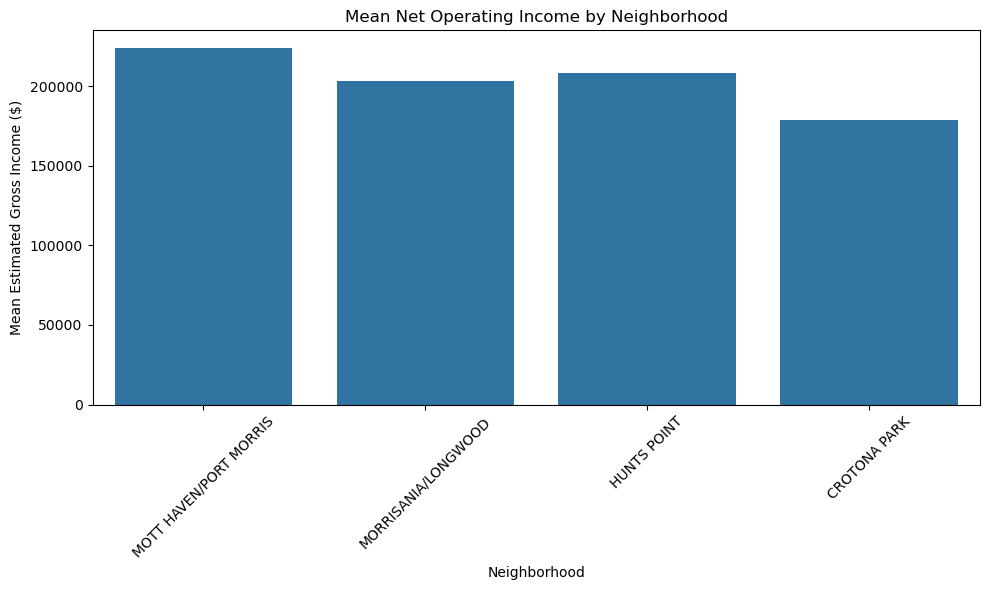

In [11]:
# Clean the string formatted numbers into floats
filtered_neighborhoods['Net Operating Income'] = filtered_neighborhoods['Net Operating Income'].astype(str).str.replace(',', '').astype(float)

# Create a bar chart showing the mean automatically
plt.figure(figsize=(10, 6))
sns.barplot(
    data=filtered_neighborhoods,
    x='Neighborhood', 
    y='Net Operating Income', 
    errorbar=None
)
# Format the chart labels
plt.title('Mean Net Operating Income by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Mean Estimated Gross Income ($)')
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()


In [13]:

filtered_neighborhoods['Total Units'] = pd.to_numeric(filtered_neighborhoods['Total Units'])

filtered_neighborhoods['rent'] = filtered_neighborhoods['Net Operating Income'] / filtered_neighborhoods['Total Units']

print(filtered_neighborhoods[['Neighborhood', 'Net Operating Income', 'Total Units', 'rent']].head())

filtered_neighborhoods


                Neighborhood  Net Operating Income  Total Units         rent
2324  MOTT HAVEN/PORT MORRIS               86977.0           11  7907.000000
2325  MOTT HAVEN/PORT MORRIS               71931.0           11  6539.181818
2326     MORRISANIA/LONGWOOD              250920.0           46  5454.782609
2327     MORRISANIA/LONGWOOD               86532.0           15  5768.800000
2328     MORRISANIA/LONGWOOD              100565.0           25  4022.600000


,Neighborhood,Building Classification,Total Units,Year Built,Estimated Gross Income,Estimated Expense,Net Operating Income,rent
2324,MOTT HAVEN/PORT MORRIS,C6 -WALK-UP,11,1905.0,"199,440","112,463",86977.0,7907.000000
2325,MOTT HAVEN/PORT MORRIS,C6 -WALK-UP,11,1931.0,"162,409","90,478",71931.0,6539.181818
2326,MORRISANIA/LONGWOOD,C6 -WALK-UP,46,1928.0,"621,062","370,142",250920.0,5454.782609
2327,MORRISANIA/LONGWOOD,C6 -WALK-UP,15,1920.0,"202,289","115,757",86532.0,5768.800000
2328,MORRISANIA/LONGWOOD,C6 -WALK-UP,25,1912.0,"241,941","141,376",100565.0,4022.600000
...,...,...,...,...,...,...,...,...
195235,MORRISANIA/LONGWOOD,D1 -ELEVATOR,42,1919.0,"571,509","358,104",213405.0,5081.071429
195236,MORRISANIA/LONGWOOD,D1 -ELEVATOR,42,1919.0,"571,509","358,104",213405.0,5081.071429
195237,MORRISANIA/LONGWOOD,D1 -ELEVATOR,42,1919.0,"533,339","358,104",175235.0,4172.261905
195239,MORRISANIA/LONGWOOD,D1 -ELEVATOR,63,1919.0,"942,378","491,984",450394.0,7149.111111


In [16]:
neighborhood_rent_means = (
    filtered_neighborhoods
    .groupby('Neighborhood')['rent']
    .mean()
    .reset_index()
    .sort_values(by='rent', ascending=False)
)
neighborhood_rent_means

,Neighborhood,rent
2,MORRISANIA/LONGWOOD,5371.543990
3,MOTT HAVEN/PORT MORRIS,5278.409325
1,HUNTS POINT,4955.606765
0,CROTONA PARK,4920.257662


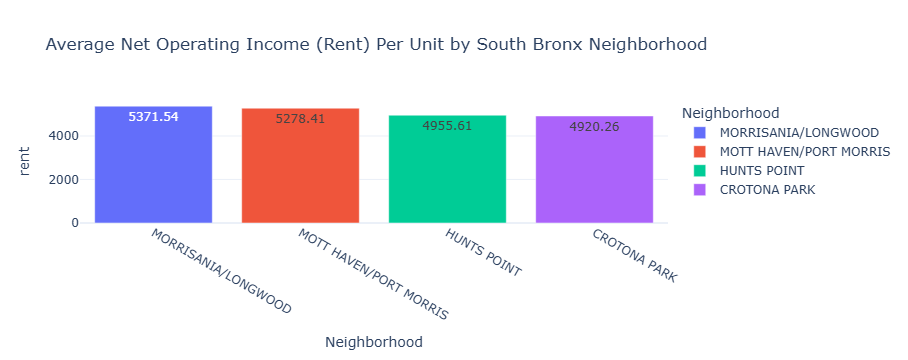

In [26]:
fig = px.bar(
    neighborhood_rent_means,
    x='Neighborhood',
    y='rent',
    title='Average Net Operating Income (Rent) Per Unit by South Bronx Neighborhood',
    labels={
        'Neighborhood': 'Neighborhood',
        'Average_Rent': 'Average Annual Rent Per Unit ($)'
    },
    text_auto='.2f',       
    color='Neighborhood',   
    template='plotly_white'
)
fig.show()